# Weights Export


In [1]:
import json

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from train import train_model
from utils import (
    create_image,
    preprocess_data,
    read_ground_truth_zip,
    export_state_dict,
)

GROUND_TRUTH_FILE = '../data/radiance/chameleon_turntable.zip'
CONFIG = 'gpu'
MODEL_ARGS_FILE = f'../data/configs/model_parameters/{CONFIG}.json'
MODEL_OUT_FILE = f'../data/models/model_{CONFIG}.zip'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
data, parameters, transfer_function = read_ground_truth_zip(
    GROUND_TRUTH_FILE, verbose=True, include_transfer_function=True
)
Xs, ys, masks = preprocess_data(data, device, verbose=True)
model_args = json.load(open(MODEL_ARGS_FILE, 'r'))

Preprocessing data: 100%|██████████| 512/512 [00:03<00:00, 128.15it/s]


In [3]:
model, *_ = train_model(Xs[:-1], ys[:-1], device, **model_args, verbose=True)

100%|██████████| 511/511 [00:20<00:00, 25.09it/s, ms=12.7, train_loss=0.0598, val_loss=0.0598]


Loss: 0.05979


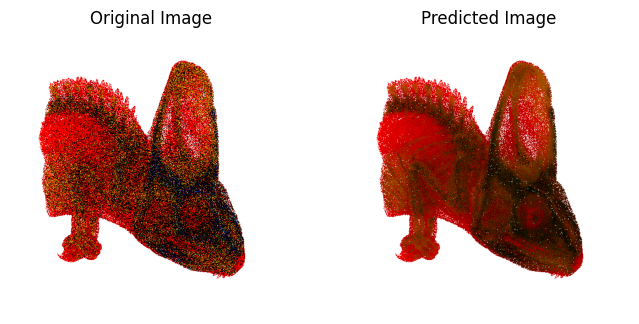

In [4]:
loss_fn = nn.MSELoss(reduction='mean')
model.eval()
with torch.no_grad():
    pred = model(Xs[-1])
loss = loss_fn(pred, ys[-1])
print(f'Loss: {loss.item():.5f}')

original = create_image(ys[-1], masks[-1], parameters['resolution'])
predicted = create_image(pred, masks[-1], parameters['resolution'])

_, ax = plt.subplots(1, 2, figsize=(8, 6))
ax[0].imshow(original)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(predicted)
ax[1].set_title('Predicted Image')
ax[1].axis('off')
plt.show()

In [5]:
total_bytes = 0

print("Model's state_dict:")
for param, tensor in model.state_dict().items():
    size_bytes = tensor.numel() * tensor.element_size()
    total_bytes += size_bytes
    print(f'{param:36} {str(tensor.size()):25} {size_bytes} B')

print(f'\nTotal size of model parameters: {total_bytes / (1024**2):.2f} MB')

Model's state_dict:
position_encoding.tables.0.weight    torch.Size([729, 4])      11664 B
position_encoding.tables.1.weight    torch.Size([1331, 4])     21296 B
position_encoding.tables.2.weight    torch.Size([2744, 4])     43904 B
position_encoding.tables.3.weight    torch.Size([6859, 4])     109744 B
position_encoding.tables.4.weight    torch.Size([15625, 4])    250000 B
position_encoding.tables.5.weight    torch.Size([32768, 4])    524288 B
position_encoding.tables.6.weight    torch.Size([79507, 4])    1272112 B
position_encoding.tables.7.weight    torch.Size([175616, 4])   2809856 B
position_encoding.tables.8.weight    torch.Size([262144, 4])   4194304 B
position_encoding.tables.9.weight    torch.Size([262144, 4])   4194304 B
position_encoding.tables.10.weight   torch.Size([262144, 4])   4194304 B
direction_encoding.tables.0.weight   torch.Size([289, 4])      4624 B
direction_encoding.tables.1.weight   torch.Size([361, 4])      5776 B
direction_encoding.tables.2.weight   torch.Siz

In [8]:
export_state_dict(
    model,
    model_args['model_args'],
    MODEL_OUT_FILE,
    parameters=parameters,
    transfer_function=transfer_function,
)